# ***Dataset Description***
The competition dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform.

The data was originally published by the NYC Taxi and Limousine Commission (TLC). The data was sampled and cleaned for the purposes of this playground competition.

Based on individual trip attributes, participants should predict the duration of each trip in the test set.


## File descriptions
train.csv - the training set (contains 1458644 trip records)

test.csv - the testing set (contains 625134 trip records)

sample_submission.csv - a sample submission file in the correct format


## Data fields
**id** - a unique identifier for each trip

**vendor_id** - a code indicating the provider associated with the trip record

**pickup_datetime** - date and time when the meter was engaged

**dropoff_datetime** - date and time when the meter was disengaged

**passenger_count** - the number of passengers in the vehicle (driver entered value)

**pickup_longitude** - the longitude where the meter was engaged

**pickup_latitude** - the latitude where the meter was engaged

**dropoff_longitude** - the longitude where the meter was disengaged

**dropoff_latitude** - the latitude where the meter was disengaged

**store_and_fwd_flag** - This flag indicates whether the trip record was held in vehicle memory before sending to the vendor because the vehicle did not have a connection to the server - Y=store and forward; N=not a store and forward trip

**trip_duration** - duration of the trip in seconds


Disclaimer: The decision was made to not remove dropoff coordinates from the dataset order to provide an expanded set of variables to use in Kernels.



In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
#reading the data
train_df = pd.read_csv(r'D:\Codes\Machine_Learning\Scikit_Learn\Homework\Datasets\nyc-taxi-trip-duration\train.csv').copy()
train_df.sort_values(by='id')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
871338,id0000001,2,2016-06-14 10:43:10,2016-06-14 11:01:35,1,-74.013924,40.713924,-73.971649,40.746407,N,1105
1004157,id0000003,2,2016-03-16 10:39:55,2016-03-16 10:57:21,5,-73.990753,40.754761,-74.007118,40.741531,N,1046
816947,id0000005,2,2016-04-25 09:50:48,2016-04-25 09:56:56,1,-73.953110,40.798580,-73.968178,40.800270,N,368
500274,id0000008,1,2016-06-15 09:57:05,2016-06-15 10:02:08,1,-74.009628,40.724762,-74.015869,40.715485,N,303
1203914,id0000009,1,2016-05-08 01:43:11,2016-05-08 01:52:18,1,-73.987991,40.759899,-73.959686,40.798504,N,547
...,...,...,...,...,...,...,...,...,...,...,...
506972,id3999988,2,2016-05-23 17:37:28,2016-05-23 18:28:33,1,-73.999329,40.724831,-74.177017,40.694901,N,3065
1433901,id3999992,2,2016-05-20 14:05:31,2016-05-20 14:07:49,1,-73.971344,40.787361,-73.978027,40.778385,N,138
69013,id3999998,2,2016-01-22 15:25:13,2016-01-22 15:49:00,1,-73.982300,40.768372,-73.952492,40.817390,N,1427
594758,id3999999,2,2016-03-15 07:14:21,2016-03-15 07:26:22,1,-74.007614,40.732471,-73.985291,40.760105,N,721


In [3]:
train_df.select_dtypes(include='number').corr()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
vendor_id,1.000000,0.287415,0.007820,0.001742,0.001528,0.004496,0.020304
passenger_count,0.287415,1.000000,0.002169,-0.005125,-0.000343,-0.002762,0.008471
pickup_longitude,0.007820,0.002169,1.000000,0.022568,0.783582,0.100190,0.026542
pickup_latitude,0.001742,-0.005125,0.022568,1.000000,0.114884,0.494038,-0.029204
dropoff_longitude,0.001528,-0.000343,0.783582,0.114884,1.000000,0.124873,0.014678
dropoff_latitude,0.004496,-0.002762,0.100190,0.494038,0.124873,1.000000,-0.020677
trip_duration,0.020304,0.008471,0.026542,-0.029204,0.014678,-0.020677,1.000000


In [4]:
test_df = pd.read_csv(r'D:\Codes\Machine_Learning\Scikit_Learn\Homework\Datasets\nyc-taxi-trip-duration\test.csv').copy()
test_df.sort_values(by='id')

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
619129,id0000002,2,2016-01-02 23:55:41,1,-73.983673,40.764481,-73.940750,40.816521,N
166124,id0000006,2,2016-05-12 19:25:47,1,-74.001411,40.730881,-73.991188,40.744617,N
563541,id0000007,1,2016-01-19 21:50:13,1,-74.006172,40.740334,-74.010674,40.708897,N
169609,id0000017,2,2016-05-11 19:26:15,1,-73.983154,40.722473,-73.968353,40.754078,N
177439,id0000018,1,2016-05-09 13:27:51,2,-73.984673,40.744293,-73.790314,40.643719,N
...,...,...,...,...,...,...,...,...,...
140721,id3999960,1,2016-05-19 19:33:21,1,-73.963806,40.768082,-73.980751,40.781937,N
44329,id3999966,1,2016-06-17 13:06:10,1,-73.954109,40.778660,-73.994949,40.750118,N
252529,id3999967,2,2016-04-18 06:54:43,1,-73.939346,40.826328,-73.946983,40.815979,N
53248,id3999981,2,2016-06-14 22:14:40,6,-73.963936,40.776844,-73.976738,40.755146,N


### Note: We need to drop the dropoff_datetime when training the model

In [5]:
train_df.columns, test_df.columns

(Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
        'passenger_count', 'pickup_longitude', 'pickup_latitude',
        'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
        'trip_duration'],
       dtype='object'),
 Index(['id', 'vendor_id', 'pickup_datetime', 'passenger_count',
        'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
        'dropoff_latitude', 'store_and_fwd_flag'],
       dtype='object'))

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [7]:
train_df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


In [8]:
train_df['lon_diff'] = abs(train_df['pickup_longitude'] - train_df['dropoff_longitude'])
train_df['lat_diff'] = abs(train_df['pickup_latitude'] - train_df['dropoff_latitude'])

In [9]:
train_df.tail()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,lon_diff,lat_diff
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,0.012711,0.005352
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,0.030762,0.049168
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,0.045303,0.061428
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,0.007446,0.008045
1458643,id1209952,1,2016-04-05 14:44:25,2016-04-05 14:47:43,1,-73.979538,40.781750,-73.972809,40.790585,N,198,0.006729,0.008835


In [10]:
train_df['pickup_datetime'].max(), train_df['pickup_datetime'].min()

('2016-06-30 23:59:39', '2016-01-01 00:00:17')

In [11]:
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])

In [12]:
train_df['Pickup_Date'] = train_df['pickup_datetime'].dt.date
train_df['Pickup_Day'] = train_df['pickup_datetime'].dt.day
train_df['Pickup_Month'] = train_df['pickup_datetime'].dt.month
train_df['Pickup_Hour'] = train_df['pickup_datetime'].dt.hour
train_df['Pickup_Day_of_week'] = train_df['pickup_datetime'].dt.day_of_week

In [13]:
train_df['dropoff_datetime'] = pd.to_datetime(train_df['dropoff_datetime'])

In [14]:
train_df['Dropoff_Date'] = train_df['dropoff_datetime'].dt.date
# train_df['Dropoff_Day'] = train_df['dropoff_datetime'].dt.day
# train_df['Dropoff_Month'] = train_df['dropoff_datetime'].dt.month
# train_df['Dropoff_Hour'] = train_df['dropoff_datetime'].dt.hour
# train_df['Dropoff_Day_of_week'] = train_df['dropoff_datetime'].dt.day_of_week

In [15]:
train_df.sort_values(by='pickup_datetime')

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,lon_diff,lat_diff,Pickup_Date,Pickup_Day,Pickup_Month,Pickup_Hour,Pickup_Day_of_week,Dropoff_Date
96469,id0190469,2,2016-01-01 00:00:17,2016-01-01 00:14:26,5,-73.981743,40.719158,-73.938828,40.829182,N,849,0.042915,0.110023,2016-01-01,1,1,0,4,2016-01-01
223872,id1665586,1,2016-01-01 00:00:53,2016-01-01 00:22:27,1,-73.985085,40.747166,-73.958038,40.717491,N,1294,0.027046,0.029675,2016-01-01,1,1,0,4,2016-01-01
713067,id1210365,2,2016-01-01 00:01:01,2016-01-01 00:07:49,5,-73.965279,40.801041,-73.947479,40.815170,N,408,0.017799,0.014130,2016-01-01,1,1,0,4,2016-01-01
652463,id3888279,1,2016-01-01 00:01:14,2016-01-01 00:05:54,1,-73.982292,40.751331,-73.991341,40.750340,N,280,0.009048,0.000992,2016-01-01,1,1,0,4,2016-01-01
722901,id0924227,1,2016-01-01 00:01:20,2016-01-01 00:13:36,1,-73.970108,40.759800,-73.989357,40.742989,N,736,0.019249,0.016811,2016-01-01,1,1,0,4,2016-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853710,id1255468,2,2016-06-30 23:58:52,2016-07-01 00:06:44,1,-73.982750,40.745289,-73.969002,40.757950,N,472,0.013748,0.012661,2016-06-30,30,6,23,3,2016-07-01
419031,id2013516,1,2016-06-30 23:59:09,2016-07-01 00:11:43,2,-73.955109,40.689564,-73.978203,40.685802,N,754,0.023094,0.003761,2016-06-30,30,6,23,3,2016-07-01
1008720,id0376262,1,2016-06-30 23:59:10,2016-07-01 00:41:36,2,-73.873093,40.774097,-73.926704,40.856739,N,2546,0.053612,0.082642,2016-06-30,30,6,23,3,2016-07-01
405743,id2332349,2,2016-06-30 23:59:37,2016-07-01 00:23:39,5,-73.998291,40.722618,-73.971779,40.762470,N,1442,0.026512,0.039852,2016-06-30,30,6,23,3,2016-07-01


In [16]:
train_df.drop(['pickup_datetime', 'dropoff_datetime', 'id'], axis=1, inplace=True)

In [17]:
train_df['Pickup_Hour'][:10]

0    17
1     0
2    11
3    19
4    13
5    22
6    22
7     7
8    23
9    21
Name: Pickup_Hour, dtype: int32

In [18]:
import numpy as np

def calculate_distance_vectorized(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

train_df['Distance'] = calculate_distance_vectorized(
    train_df['pickup_latitude'],
    train_df['pickup_longitude'],
    train_df['dropoff_latitude'],
    train_df['dropoff_longitude']
)


## MOST IMPORTANT FEATURE ENGINEERING PART

In [19]:
# Rush hour and weekend features
train_df['is_rush_hour'] = train_df['Pickup_Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
train_df['is_weekend'] = train_df['Pickup_Day_of_week'].isin([5, 6]).astype(int)

# Time of day categories
train_df['is_night'] = train_df['Pickup_Hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
train_df['is_morning'] = train_df['Pickup_Hour'].isin([6, 7, 8, 9, 10, 11]).astype(int)
train_df['is_afternoon'] = train_df['Pickup_Hour'].isin([12, 13, 14, 15, 16]).astype(int)
train_df['is_evening'] = train_df['Pickup_Hour'].isin([17, 18, 19, 20, 21]).astype(int)

# Distance categories
train_df['short_distance'] = (train_df['Distance'] < 3).astype(int)
train_df['medium_distance'] = ((train_df['Distance'] >= 3) & (train_df['Distance'] < 10)).astype(int)
train_df['long_distance'] = (train_df['Distance'] >= 10).astype(int)

# Location-based features (NYC boroughs approximation)
# Manhattan roughly: lat 40.7-40.8, lon -74.0 to -73.9
train_df['pickup_is_manhattan'] = ((train_df['pickup_latitude'] >= 40.7) & 
                                   (train_df['pickup_latitude'] <= 40.82) &
                                   (train_df['pickup_longitude'] >= -74.02) & 
                                   (train_df['pickup_longitude'] <= -73.93)).astype(int)

train_df['dropoff_is_manhattan'] = ((train_df['dropoff_latitude'] >= 40.7) & 
                                    (train_df['dropoff_latitude'] <= 40.82) &
                                    (train_df['dropoff_longitude'] >= -74.02) & 
                                    (train_df['dropoff_longitude'] <= -73.93)).astype(int)

# Cross-borough trip
train_df['cross_borough'] = (train_df['pickup_is_manhattan'] != train_df['dropoff_is_manhattan']).astype(int)

# Month-based features (season approximation)
train_df['is_summer'] = train_df['Pickup_Month'].isin([6, 7, 8]).astype(int)
train_df['is_winter'] = train_df['Pickup_Month'].isin([12, 1, 2]).astype(int)

# Day-based features
train_df['is_monday'] = (train_df['Pickup_Day_of_week'] == 0).astype(int)
train_df['is_friday'] = (train_df['Pickup_Day_of_week'] == 4).astype(int)

# Passenger count interactions (if relevant)
train_df['high_passenger_count'] = (train_df['passenger_count'] > 3).astype(int)
train_df['solo_passenger'] = (train_df['passenger_count'] == 1).astype(int)

# Distance-time interaction features
train_df['distance_hour_interaction'] = train_df['Distance'] * train_df['Pickup_Hour'] / 24

# Longitude differences in absolute grid terms
train_df['lon_grid'] = (train_df['lon_diff'] * 111).astype(int)  # Convert degrees to km
train_df['lat_grid'] = (train_df['lat_diff'] * 111).astype(int)  # Convert degrees to km


# OUTLIER REMOVAL: Filter based on realistic speed
# Calculate speed for filtering (km/h)
train_df['speed'] = train_df['Distance'] / np.maximum(train_df['trip_duration'] / 3600, 0.01)

# Filter outliers: Keep only trips with realistic city speeds (2-80 km/h)
print(f"Original dataset size: {len(train_df)}")
train_df = train_df[(train_df['speed'] > 2) & (train_df['speed'] < 80)]
print(f"After speed filtering: {len(train_df)}")
print(f"Removed outliers: {1458644 - len(train_df)} rows")

# CRITICAL: Drop the speed column before creating features
train_df = train_df.drop('speed', axis=1)


Original dataset size: 1458644
After speed filtering: 1440735
Removed outliers: 17909 rows


In [20]:
# Apply same preprocessing to test data
test_df['lon_diff'] = abs(test_df['pickup_longitude'] - test_df['dropoff_longitude'])
test_df['lat_diff'] = abs(test_df['pickup_latitude'] - test_df['dropoff_latitude'])
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'])
test_df['Pickup_Date'] = test_df['pickup_datetime'].dt.date
test_df['Pickup_Day'] = test_df['pickup_datetime'].dt.day
test_df['Pickup_Month'] = test_df['pickup_datetime'].dt.month
test_df['Pickup_Hour'] = test_df['pickup_datetime'].dt.hour
test_df['Pickup_Day_of_week'] = test_df['pickup_datetime'].dt.day_of_week
test_df['Distance'] = calculate_distance_vectorized(
    test_df['pickup_latitude'],
    test_df['pickup_longitude'],
    test_df['dropoff_latitude'],
    test_df['dropoff_longitude']
)
test_df.drop(['pickup_datetime', 'id', 'Pickup_Date'], axis=1, inplace=True)

# Apply all the feature engineering
test_df['is_rush_hour'] = test_df['Pickup_Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
test_df['is_weekend'] = test_df['Pickup_Day_of_week'].isin([5, 6]).astype(int)
test_df['is_night'] = test_df['Pickup_Hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
test_df['is_morning'] = test_df['Pickup_Hour'].isin([6, 7, 8, 9, 10, 11]).astype(int)
test_df['is_afternoon'] = test_df['Pickup_Hour'].isin([12, 13, 14, 15, 16]).astype(int)
test_df['is_evening'] = test_df['Pickup_Hour'].isin([17, 18, 19, 20, 21]).astype(int)

test_df['short_distance'] = (test_df['Distance'] < 3).astype(int)
test_df['medium_distance'] = ((test_df['Distance'] >= 3) & (test_df['Distance'] < 10)).astype(int)
test_df['long_distance'] = (test_df['Distance'] >= 10).astype(int)

test_df['pickup_is_manhattan'] = ((test_df['pickup_latitude'] >= 40.7) & 
                                   (test_df['pickup_latitude'] <= 40.82) &
                                   (test_df['pickup_longitude'] >= -74.02) & 
                                   (test_df['pickup_longitude'] <= -73.93)).astype(int)

test_df['dropoff_is_manhattan'] = ((test_df['dropoff_latitude'] >= 40.7) & 
                                    (test_df['dropoff_latitude'] <= 40.82) &
                                    (test_df['dropoff_longitude'] >= -74.02) & 
                                    (test_df['dropoff_longitude'] <= -73.93)).astype(int)

test_df['cross_borough'] = (test_df['pickup_is_manhattan'] != test_df['dropoff_is_manhattan']).astype(int)

test_df['is_summer'] = test_df['Pickup_Month'].isin([6, 7, 8]).astype(int)
test_df['is_winter'] = test_df['Pickup_Month'].isin([12, 1, 2]).astype(int)

test_df['is_monday'] = (test_df['Pickup_Day_of_week'] == 0).astype(int)
test_df['is_friday'] = (test_df['Pickup_Day_of_week'] == 4).astype(int)

test_df['high_passenger_count'] = (test_df['passenger_count'] > 3).astype(int)
test_df['solo_passenger'] = (test_df['passenger_count'] == 1).astype(int)

test_df['distance_hour_interaction'] = test_df['Distance'] * test_df['Pickup_Hour'] / 24

test_df['lon_grid'] = (test_df['lon_diff'] * 111).astype(int)
test_df['lat_grid'] = (test_df['lat_diff'] * 111).astype(int)

In [21]:
train_df.tail()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,lon_diff,lat_diff,...,cross_borough,is_summer,is_winter,is_monday,is_friday,high_passenger_count,solo_passenger,distance_hour_interaction,lon_grid,lat_grid
1458639,2,4,-73.982201,40.745522,-73.994911,40.740170,N,778,0.012711,0.005352,...,0,0,0,0,1,1,0,0.663585,1,0
1458640,1,1,-74.000946,40.747379,-73.970184,40.796547,N,655,0.030762,0.049168,...,0,0,1,0,0,0,1,1.764535,3,5
1458641,2,1,-73.959129,40.768799,-74.004433,40.707371,N,764,0.045303,0.061428,...,0,0,0,0,1,0,1,1.956151,5,6
1458642,1,1,-73.982079,40.749062,-73.974632,40.757107,N,373,0.007446,0.008045,...,0,0,1,0,0,0,1,0.682852,0,0
1458643,1,1,-73.979538,40.781750,-73.972809,40.790585,N,198,0.006729,0.008835,...,0,0,0,0,0,0,1,0.661524,0,0


In [22]:
train_df.drop(['Pickup_Date', 'Dropoff_Date'], axis=1, inplace=True)

In [23]:
train_df.columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'lon_diff', 'lat_diff', 'Pickup_Day', 'Pickup_Month',
       'Pickup_Hour', 'Pickup_Day_of_week', 'Distance', 'is_rush_hour',
       'is_weekend', 'is_night', 'is_morning', 'is_afternoon', 'is_evening',
       'short_distance', 'medium_distance', 'long_distance',
       'pickup_is_manhattan', 'dropoff_is_manhattan', 'cross_borough',
       'is_summer', 'is_winter', 'is_monday', 'is_friday',
       'high_passenger_count', 'solo_passenger', 'distance_hour_interaction',
       'lon_grid', 'lat_grid'],
      dtype='object')

In [24]:
train_df['trip_duration'].max(), train_df['trip_duration'].min()

(85561, 1)

## Visualizing the data

In [25]:
vis = train_df.sample(5000)

Text(0.5, 1.0, 'Distance Vs Time Graph')

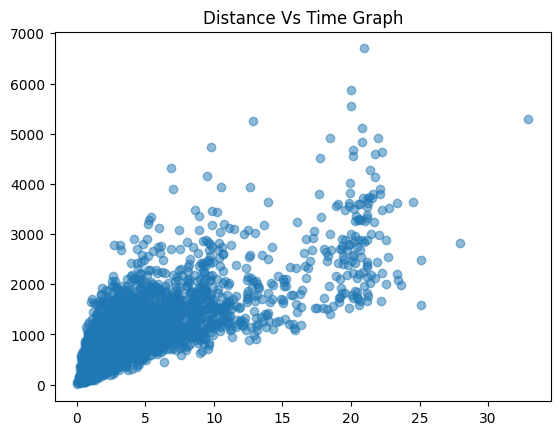

In [26]:
#px.scatter(train_df, x = train_df.Distance, y = train_df.trip_duration, color=train_df.trip_duration)
plt.scatter(vis['Distance'], vis['trip_duration'], alpha=0.5)
plt.title('Distance Vs Time Graph')

Text(0, 0.5, 'Trip Duration')

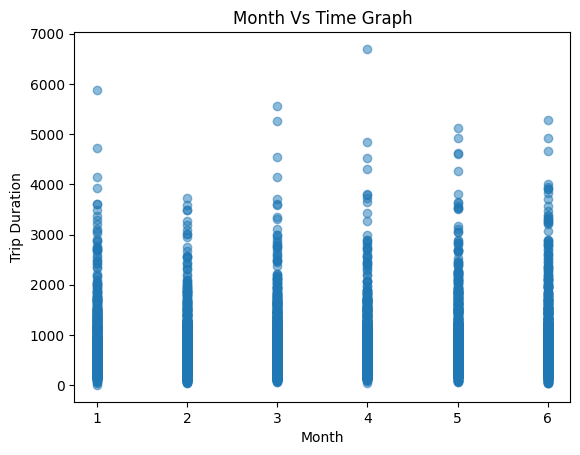

In [27]:
plt.scatter(vis['Pickup_Month'], vis['trip_duration'], alpha=0.5)
plt.title('Month Vs Time Graph')
plt.xlabel('Month')
plt.ylabel('Trip Duration')

Text(0, 0.5, 'Trip Duration')

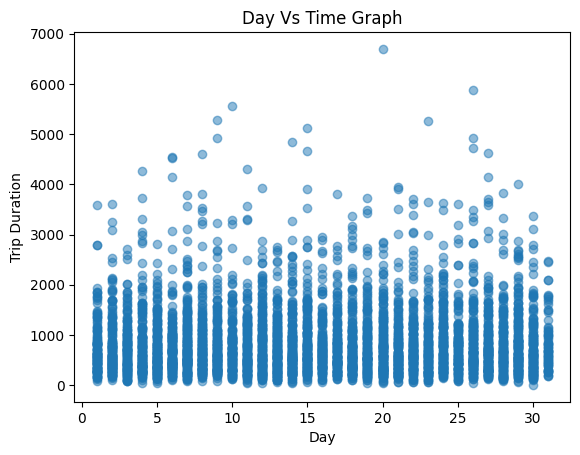

In [28]:
plt.scatter(vis['Pickup_Day'], vis['trip_duration'], alpha=0.5)
plt.title('Day Vs Time Graph')
plt.xlabel('Day')
plt.ylabel('Trip Duration')

Text(0, 0.5, 'Trip Duration')

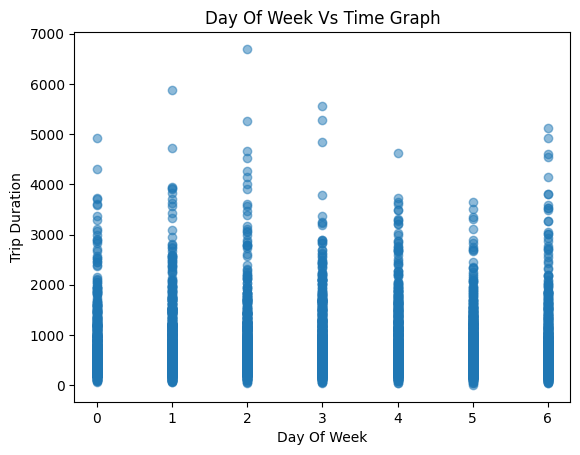

In [29]:
plt.scatter(vis['Pickup_Day_of_week'], vis['trip_duration'], alpha=0.5)
plt.title('Day Of Week Vs Time Graph')
plt.xlabel('Day Of Week')
plt.ylabel('Trip Duration')

Text(0, 0.5, 'Trip Duration')

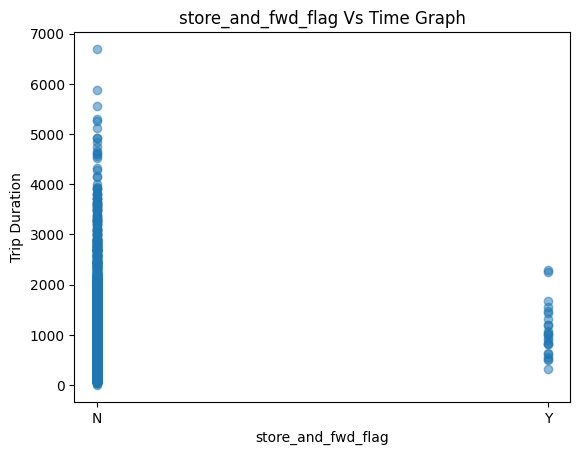

In [30]:
plt.scatter(vis['store_and_fwd_flag'], vis['trip_duration'], alpha=0.5)
plt.title('store_and_fwd_flag Vs Time Graph')
plt.xlabel('store_and_fwd_flag')
plt.ylabel('Trip Duration')

In [31]:
# plt.scatter(vis['pickup_latitude'], vis['Distance'], alpha=0.5)
# plt.title('store_and_fwd_flag Vs Distance Graph')
# plt.xlabel('store_and_fwd_flag')
# plt.ylabel('Distnace')

px.scatter(vis, x='pickup_latitude', y='trip_duration', opacity=0.6)

#### Removing extra columns related to dropoff datetime

In [32]:
train_df.columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'lon_diff', 'lat_diff', 'Pickup_Day', 'Pickup_Month',
       'Pickup_Hour', 'Pickup_Day_of_week', 'Distance', 'is_rush_hour',
       'is_weekend', 'is_night', 'is_morning', 'is_afternoon', 'is_evening',
       'short_distance', 'medium_distance', 'long_distance',
       'pickup_is_manhattan', 'dropoff_is_manhattan', 'cross_borough',
       'is_summer', 'is_winter', 'is_monday', 'is_friday',
       'high_passenger_count', 'solo_passenger', 'distance_hour_interaction',
       'lon_grid', 'lat_grid'],
      dtype='object')

In [33]:
# train_df.drop(['Dropoff_Day', 'Dropoff_Month', 'Dropoff_Hour', 'Dropoff_Day_of_week'], axis=1, inplace=True)
# train_df.columns

## Numeric and Catagorical Columns

In [34]:
numeric_cols = (train_df.select_dtypes(include='number').columns).tolist()
numeric_cols.remove('trip_duration')
numeric_cols.remove('vendor_id')
cat_cols = train_df.select_dtypes(include='object').columns

In [35]:

# Recalculate numeric and categorical columns after feature engineering
numeric_cols = (train_df.select_dtypes(include='number').columns).tolist()
numeric_cols.remove('trip_duration')
if 'vendor_id' in numeric_cols:
    numeric_cols.remove('vendor_id')
cat_cols = train_df.select_dtypes(include='object').columns

In [36]:
numeric_cols, cat_cols

(['passenger_count',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'lon_diff',
  'lat_diff',
  'Pickup_Day',
  'Pickup_Month',
  'Pickup_Hour',
  'Pickup_Day_of_week',
  'Distance',
  'is_rush_hour',
  'is_weekend',
  'is_night',
  'is_morning',
  'is_afternoon',
  'is_evening',
  'short_distance',
  'medium_distance',
  'long_distance',
  'pickup_is_manhattan',
  'dropoff_is_manhattan',
  'cross_borough',
  'is_summer',
  'is_winter',
  'is_monday',
  'is_friday',
  'high_passenger_count',
  'solo_passenger',
  'distance_hour_interaction',
  'lon_grid',
  'lat_grid'],
 Index(['store_and_fwd_flag'], dtype='object'))

## Scalling the data

In [37]:
from sklearn.preprocessing import MinMaxScaler

In [38]:
scaler = MinMaxScaler().fit(train_df[numeric_cols])

In [39]:
train_df[numeric_cols] = scaler.transform(train_df[numeric_cols])
#test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [40]:
# Scale numeric columns
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])
test_df_cat_cols = test_df[cat_cols]

## Encoding of Categorical Columns

In [41]:
from sklearn.preprocessing import OneHotEncoder

In [42]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[cat_cols])

In [43]:
encoded_cols = encoder.get_feature_names_out().tolist()
encoded_cols

['store_and_fwd_flag_N', 'store_and_fwd_flag_Y']

In [44]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440735 entries, 0 to 1458643
Data columns (total 36 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   vendor_id                  1440735 non-null  int64  
 1   passenger_count            1440735 non-null  float64
 2   pickup_longitude           1440735 non-null  float64
 3   pickup_latitude            1440735 non-null  float64
 4   dropoff_longitude          1440735 non-null  float64
 5   dropoff_latitude           1440735 non-null  float64
 6   store_and_fwd_flag         1440735 non-null  object 
 7   trip_duration              1440735 non-null  int64  
 8   lon_diff                   1440735 non-null  float64
 9   lat_diff                   1440735 non-null  float64
 10  Pickup_Day                 1440735 non-null  float64
 11  Pickup_Month               1440735 non-null  float64
 12  Pickup_Hour                1440735 non-null  float64
 13  Pickup_Day_of_wee

In [45]:
train_df[encoded_cols] = encoder.transform(train_df[cat_cols])
train_df

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,lon_diff,lat_diff,...,is_winter,is_monday,is_friday,high_passenger_count,solo_passenger,distance_hour_interaction,lon_grid,lat_grid,store_and_fwd_flag_N,store_and_fwd_flag_Y
0,2,0.166667,0.664480,0.509283,0.634020,0.360052,N,455,0.008135,0.002583,...,0.0,1.0,0.0,0.0,1.0,0.006050,0.004184,0.00,1.0,0.0
1,1,0.166667,0.665264,0.493766,0.623842,0.336288,N,663,0.008850,0.008201,...,0.0,0.0,0.0,0.0,1.0,0.000000,0.008368,0.00,1.0,0.0
2,2,0.166667,0.665890,0.507171,0.622133,0.321758,N,2124,0.012211,0.059585,...,1.0,0.0,0.0,0.0,1.0,0.016680,0.008368,0.05,1.0,0.0
3,2,0.166667,0.651907,0.483943,0.620108,0.319435,N,429,0.001034,0.014663,...,0.0,0.0,0.0,0.0,1.0,0.006703,0.000000,0.01,1.0,0.0
4,2,0.166667,0.668584,0.522635,0.631598,0.371722,N,435,0.000060,0.011827,...,0.0,0.0,0.0,0.0,1.0,0.003669,0.000000,0.01,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,0.666667,0.664459,0.497442,0.625177,0.342509,N,778,0.005900,0.005922,...,0.0,0.0,1.0,1.0,0.0,0.003782,0.004184,0.00,1.0,0.0
1458640,1,0.166667,0.656008,0.498423,0.632398,0.381397,N,655,0.014280,0.054401,...,1.0,0.0,0.0,0.0,1.0,0.010057,0.012552,0.05,1.0,0.0
1458641,2,0.166667,0.674862,0.509739,0.622396,0.319885,N,764,0.021030,0.067967,...,0.0,0.0,1.0,0.0,1.0,0.011149,0.020921,0.06,1.0,0.0
1458642,1,0.166667,0.664514,0.499312,0.631099,0.354192,N,373,0.003457,0.008902,...,1.0,0.0,0.0,0.0,1.0,0.003892,0.000000,0.00,1.0,0.0


In [46]:
test_encoded = encoder.transform(test_df_cat_cols)
test_df[encoded_cols] = test_encoded

In [47]:
input_df = train_df[numeric_cols + encoded_cols]
input_df.tail

<bound method NDFrame.tail of          passenger_count  pickup_longitude  pickup_latitude  \
0               0.166667          0.664480         0.509283   
1               0.166667          0.665264         0.493766   
2               0.166667          0.665890         0.507171   
3               0.166667          0.651907         0.483943   
4               0.166667          0.668584         0.522635   
...                  ...               ...              ...   
1458639         0.666667          0.664459         0.497442   
1458640         0.166667          0.656008         0.498423   
1458641         0.166667          0.674862         0.509739   
1458642         0.166667          0.664514         0.499312   
1458643         0.166667          0.665660         0.516581   

         dropoff_longitude  dropoff_latitude  lon_diff  lat_diff  Pickup_Day  \
0                 0.634020          0.360052  0.008135  0.002583    0.433333   
1                 0.623842          0.336288  0.00885

## Train/Val Split

In [48]:
X = input_df.columns.tolist()
target_col = 'trip_duration'

In [49]:
len(train_df)

1440735

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_val, train_target, val_target = train_test_split(
    input_df[X], 
    train_df[target_col], 
    test_size=0.25, 
    random_state=54
)

In [51]:
len(X_train), len(X_val)

(1080551, 360184)

In [52]:
'speep' in X_train.columns

False

## Training Model

In [53]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_log_error

Creating a baseline model which always predicts the mean of the trip_duration

In [54]:
def mean_model(x, y):
    loss = y.sum() - y.mean()
    return loss

In [55]:
mean_model(X_train, train_target), mean_model(X_val, val_target)

(906665870.9218723, 301669437.4550924)

In [56]:
train_target.sum(), train_target.mean(), val_target.sum(), val_target.mean()

(906666710, 839.0781277329806, 301670275, 837.5449076027808)

In [57]:
X_train.size

37819285

### Using DesicionTreeRegressor

In [58]:
dtr = DecisionTreeRegressor(
    criterion='absolute_error',
    max_depth=20,            # Limit tree depth to prevent overfitting
    min_samples_split=10,    # Require at least 10 samples to split
    min_samples_leaf=5,      # Require minimum 5 samples in leaf nodes
    random_state=54
).fit(X_train, train_target)

In [59]:
prediction = dtr.predict(X_train)
print('Train Score: ', dtr.score(X_train, train_target))
print(mean_absolute_error(train_target, prediction), r2_score(train_target, prediction))
print(root_mean_squared_log_error(train_target, prediction))
prediction = dtr.predict(X_val)
print('Val_Score: ', dtr.score(X_val, val_target))
print(mean_absolute_error(val_target, prediction), r2_score(val_target, prediction))
print(root_mean_squared_log_error(val_target, prediction))

Train Score:  0.821903058858365
141.4341988485504 0.821903058858365
0.2818742543093776
Val_Score:  0.7525961303463767
203.15285243097972 0.7525961303463767
0.3644513497937065


In [60]:
dtr.get_depth()

20

### Using RandomForestRegressor

In [61]:
rfr = RandomForestRegressor(n_estimators=100,
                            criterion='squared_error',
                            max_depth=15,
                            max_leaf_nodes=7,
                            min_samples_split=10,
                            #max_features='sqrt',
                            n_jobs=-1,
                            verbose=20,
                            random_state=54).fit(X_train, train_target)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 2 of 100building tree 3 of 100
building tree 1 of 100
building tree 4 of 100
building tree 5 of 100

building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   13.0s


building tree 14 of 100
building tree 15 of 100
building tree 16 of 100


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:   14.2s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:   14.2s


building tree 17 of 100
building tree 18 of 100
building tree 19 of 100


[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   14.4s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   14.4s


building tree 20 of 100


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   15.1s


building tree 21 of 100


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   18.8s


building tree 22 of 100


[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   19.6s


building tree 23 of 100


[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   20.1s


building tree 24 of 100


[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   23.8s


building tree 25 of 100


[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   27.1s


building tree 26 of 100


[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   28.3s


building tree 27 of 100


[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   28.8s


building tree 28 of 100


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   29.2s


building tree 29 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:   29.4s


building tree 30 of 100


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   30.0s


building tree 31 of 100


[Parallel(n_jobs=-1)]: Done  19 tasks      | elapsed:   30.6s


building tree 32 of 100


[Parallel(n_jobs=-1)]: Done  20 tasks      | elapsed:   32.3s


building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:   33.6s


building tree 34 of 100


[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:   36.1s


building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  23 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:   37.6s


building tree 37 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   39.9s


building tree 38 of 100


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   40.6s


building tree 39 of 100
building tree 40 of 100
building tree 41 of 100


[Parallel(n_jobs=-1)]: Done  27 tasks      | elapsed:   42.2s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   42.3s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   42.4s


building tree 42 of 100


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   43.4s


building tree 43 of 100


[Parallel(n_jobs=-1)]: Done  31 tasks      | elapsed:   45.9s


building tree 44 of 100


[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   48.1s


building tree 45 of 100


[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:   50.7s


building tree 46 of 100


[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   51.1s


building tree 47 of 100


[Parallel(n_jobs=-1)]: Done  35 tasks      | elapsed:   53.0s


building tree 48 of 100


[Parallel(n_jobs=-1)]: Done  36 tasks      | elapsed:   53.5s


building tree 49 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:   54.0s


building tree 50 of 100


[Parallel(n_jobs=-1)]: Done  38 tasks      | elapsed:   55.0s


building tree 51 of 100


[Parallel(n_jobs=-1)]: Done  39 tasks      | elapsed:   55.5s


building tree 52 of 100


[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   56.4s


building tree 53 of 100


[Parallel(n_jobs=-1)]: Done  41 tasks      | elapsed:   56.9s


building tree 54 of 100


[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   57.7s


building tree 55 of 100


[Parallel(n_jobs=-1)]: Done  43 tasks      | elapsed:  1.0min


building tree 56 of 100


[Parallel(n_jobs=-1)]: Done  44 tasks      | elapsed:  1.1min


building tree 57 of 100
building tree 58 of 100


[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min


building tree 59 of 100


[Parallel(n_jobs=-1)]: Done  47 tasks      | elapsed:  1.1min


building tree 60 of 100


[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:  1.1min


building tree 61 of 100


[Parallel(n_jobs=-1)]: Done  49 tasks      | elapsed:  1.2min


building tree 62 of 100
building tree 63 of 100


[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  51 tasks      | elapsed:  1.2min


building tree 64 of 100
building tree 65 of 100


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:  1.2min


building tree 66 of 100


[Parallel(n_jobs=-1)]: Done  54 tasks      | elapsed:  1.2min


building tree 67 of 100


[Parallel(n_jobs=-1)]: Done  55 tasks      | elapsed:  1.3min


building tree 68 of 100


[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:  1.3min


building tree 69 of 100


[Parallel(n_jobs=-1)]: Done  57 tasks      | elapsed:  1.4min


building tree 70 of 100


[Parallel(n_jobs=-1)]: Done  58 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  59 tasks      | elapsed:  1.4min


building tree 71 of 100
building tree 72 of 100


[Parallel(n_jobs=-1)]: Done  60 tasks      | elapsed:  1.4min


building tree 73 of 100


[Parallel(n_jobs=-1)]: Done  61 tasks      | elapsed:  1.4min


building tree 74 of 100


[Parallel(n_jobs=-1)]: Done  62 tasks      | elapsed:  1.4min


building tree 75 of 100
building tree 76 of 100


[Parallel(n_jobs=-1)]: Done  63 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:  1.4min


building tree 77 of 100


[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:  1.4min


building tree 78 of 100


[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:  1.4min


building tree 79 of 100


[Parallel(n_jobs=-1)]: Done  67 tasks      | elapsed:  1.5min


building tree 80 of 100


[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:  1.6min


building tree 81 of 100


[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:  1.6min


building tree 82 of 100
building tree 83 of 100


[Parallel(n_jobs=-1)]: Done  70 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  71 tasks      | elapsed:  1.6min


building tree 84 of 100
building tree 85 of 100


[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done  73 tasks      | elapsed:  1.6min


building tree 86 of 100


[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:  1.6min


building tree 87 of 100
building tree 88 of 100


[Parallel(n_jobs=-1)]: Done  75 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:  1.7min


building tree 89 of 100


[Parallel(n_jobs=-1)]: Done  77 tasks      | elapsed:  1.7min


building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100


[Parallel(n_jobs=-1)]: Done  83 out of 100 | elapsed:  1.9min remaining:   23.1s


building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100


[Parallel(n_jobs=-1)]: Done  89 out of 100 | elapsed:  1.9min remaining:   14.4s
[Parallel(n_jobs=-1)]: Done  95 out of 100 | elapsed:  2.1min remaining:    6.6s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.1min finished


In [62]:
#train score
prediction = rfr.predict(X_train)
print('Test: ')
print(mean_absolute_error(train_target, prediction), r2_score(train_target, prediction))
print(root_mean_squared_log_error(train_target, prediction))

#validation score
prediction = rfr.predict(X_val)
print('Val: ')
print(mean_absolute_error(val_target, prediction), r2_score(val_target, prediction))
print(root_mean_squared_log_error(val_target, prediction))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   5 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   6 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done   9 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  10 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  11 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  12 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  13 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  14 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done  15 tasks      | elaps

Test: 
274.55078349453345 0.6083732313014344
0.4883470400997249


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   5 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   7 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  11 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  12 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  13 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  15 tasks      | elaps

Val: 
273.95032718116687 0.6180728627532728
0.48716685409865945


[Parallel(n_jobs=12)]: Done  75 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  76 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  77 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  83 out of 100 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  89 out of 100 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=12)]: Done  95 out of 100 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.2s finished


### Using XGBoost

In [63]:
from xgboost import XGBRegressor

In [64]:
xgbr = XGBRegressor(n_estimators=200,
                    max_depth=10,
                    learning_rate=.02,
                    tree_method='hist',
                    n_jobs=-1,
                    early_stopping_rounds=50)
xgbr.fit(X_train, train_target,
         eval_set=[(X_val, val_target)], 
         #early_stopping_rounds=50,
         verbose=20)

[0]	validation_0-rmse:648.07325
[20]	validation_0-rmse:496.49371
[40]	validation_0-rmse:408.50260
[60]	validation_0-rmse:359.30366
[80]	validation_0-rmse:332.09129
[100]	validation_0-rmse:316.74597
[120]	validation_0-rmse:307.51531
[140]	validation_0-rmse:301.48145
[160]	validation_0-rmse:297.33902
[180]	validation_0-rmse:294.24116
[199]	validation_0-rmse:291.84495


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [65]:
#train score
prediction = xgbr.predict(X_train)
print('Test: ')
print(mean_absolute_error(train_target, prediction), r2_score(train_target, prediction))
#print(root_mean_squared_log_error(train_target, prediction))

#validation score
prediction = xgbr.predict(X_val)
print('Val: ')
print(mean_absolute_error(val_target, prediction), r2_score(val_target, prediction))
#print(root_mean_squared_log_error(val_target, prediction))

Test: 
178.5659942626953 0.8171567320823669
Val: 
182.60044860839844 0.8032116889953613


In [66]:
# Force all predictions to be at least 0
prediction = xgbr.predict(X_val)
prediction = np.maximum(prediction, 0) 

# Now calculate the error
print(root_mean_squared_log_error(val_target, prediction))

0.3367355167865753


In [67]:
xgbr = XGBRegressor(n_estimators=100,
                    max_depth=8,
                    learning_rate=.02,
                    subsample=0.6,
                    colsample_bytree=0.5,
                    tree_method='hist',
                    n_jobs=-1)
xgbr.fit(X_train, train_target,
         eval_set=[(X_val, val_target)], 
         verbose=100)

[0]	validation_0-rmse:648.59049
[99]	validation_0-rmse:334.67991


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [73]:
#train score
xgb_test_prediction = xgbr.predict(X_train)
print('Test: ')
print(mean_absolute_error(train_target, xgb_test_prediction), r2_score(train_target, xgb_test_prediction))
#print(root_mean_squared_log_error(train_target, prediction))

#validation score
xgb_val_prediction = xgbr.predict(X_val)
print('Val: ')
print(mean_absolute_error(val_target, xgb_val_prediction), r2_score(val_target, xgb_val_prediction))
#print(root_mean_squared_log_error(val_target, prediction))

Test: 
217.7372589111328 0.7339686155319214
Val: 
217.77032470703125 0.7412060499191284


In [75]:
# Force all predictions to be at least 0
prediction = xgbr.predict(X_val)
prediction = np.maximum(xgb_val_prediction, 0) 

# Now calculate the error
print(root_mean_squared_log_error(val_target, prediction))

0.4170224964618683


### Vaisulization of the Prediction and Target Values - Output

| Visualization     | Purpose                               |
| ----------------- | ------------------------------------- |
| Line Plot         | Compare prediction vs actual sequence |
| Scatter Plot      | Check prediction accuracy             |
| Residual Plot     | Analyze errors                        |
| Distribution Plot | Compare statistical distribution      |


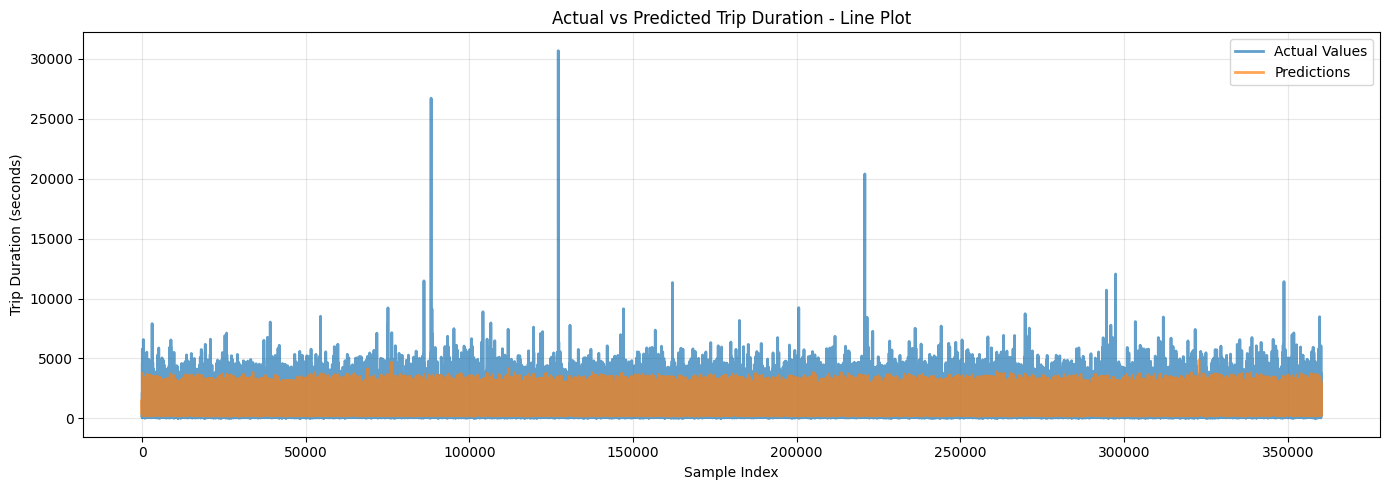

In [83]:
# 1. LINE PLOT - Direct comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(val_target.values, label='Actual Values', linewidth=2, alpha=0.7)
ax.plot(xgb_val_prediction, label='Predictions', linewidth=2, alpha=0.7)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Trip Duration (seconds)')
ax.set_title('Actual vs Predicted Trip Duration - Line Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### How we get a straight line at 45 deg angle:

The plt.plot() function connects points in the order they are provided. By passing two lists—one for X coordinates and one for Y coordinates—you are defining two specific points on the Cartesian plane:

Point A (Start): `(min_val, min_val)`

Point B (End): `(max_val, max_val)`

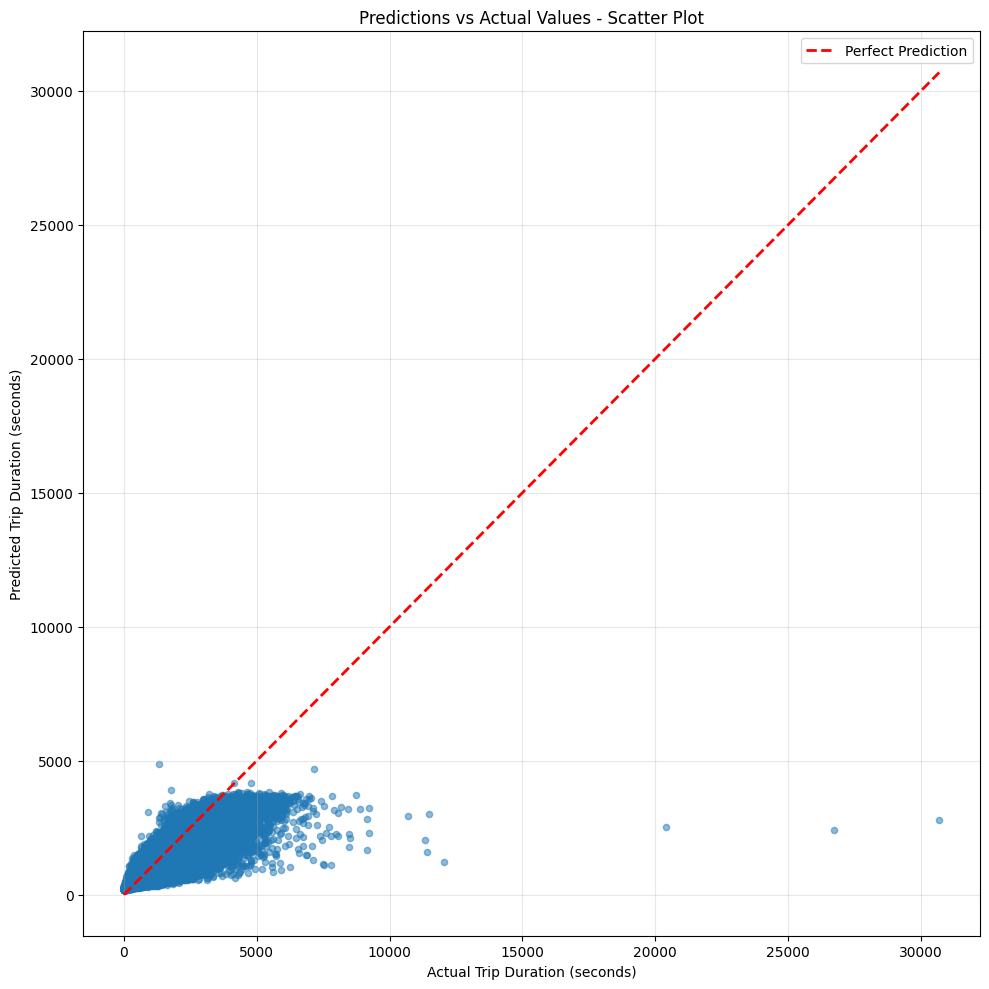

In [84]:
# 2. SCATTER PLOT - Predictions vs Actual (Perfect fit = diagonal line)
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(val_target.values, xgb_val_prediction, alpha=0.5, s=20)
# Add diagonal line for perfect prediction
min_val = min(val_target.min(), xgb_val_prediction.min())
max_val = max(val_target.max(), xgb_val_prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Trip Duration (seconds)')
ax.set_ylabel('Predicted Trip Duration (seconds)')
ax.set_title('Predictions vs Actual Values - Scatter Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

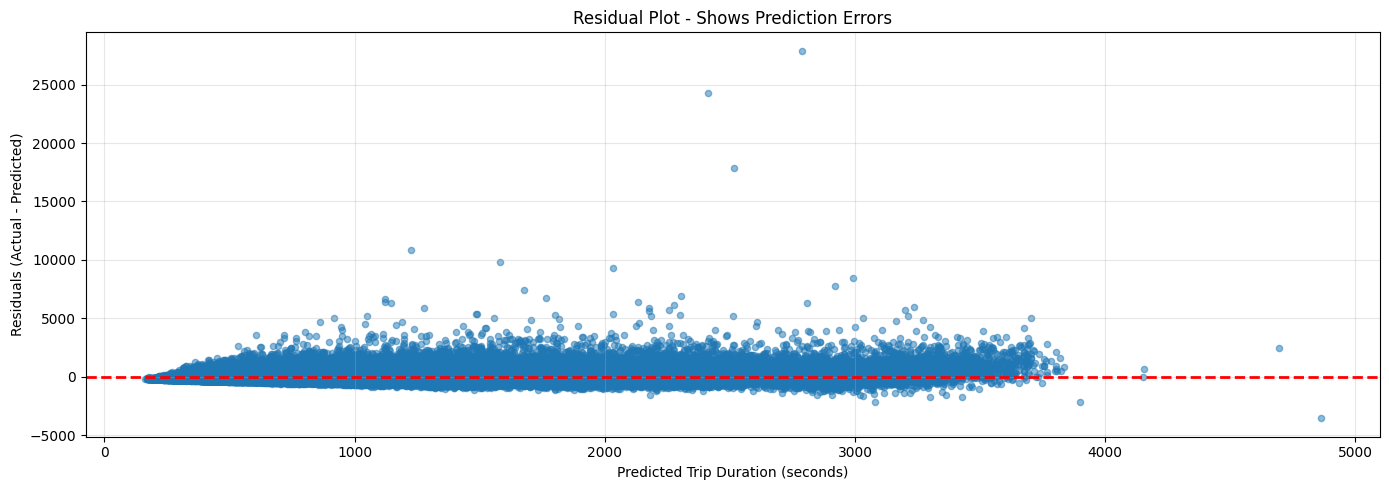

Mean Residual: -0.61
Std Dev of Residuals: 334.68
Max Error: 27897.84
Min Error: -3552.05


In [85]:
# 3. RESIDUAL PLOT - Shows prediction errors
residuals = val_target.values - xgb_val_prediction
fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(xgb_val_prediction, residuals, alpha=0.5, s=20)
ax.axhline(y=0, color='r', lw=2, linestyle='--')
ax.set_xlabel('Predicted Trip Duration (seconds)')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title('Residual Plot - Shows Prediction Errors')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print residual statistics
print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Dev of Residuals: {residuals.std():.2f}")
print(f"Max Error: {abs(residuals).max():.2f}")
print(f"Min Error: {residuals.min():.2f}")

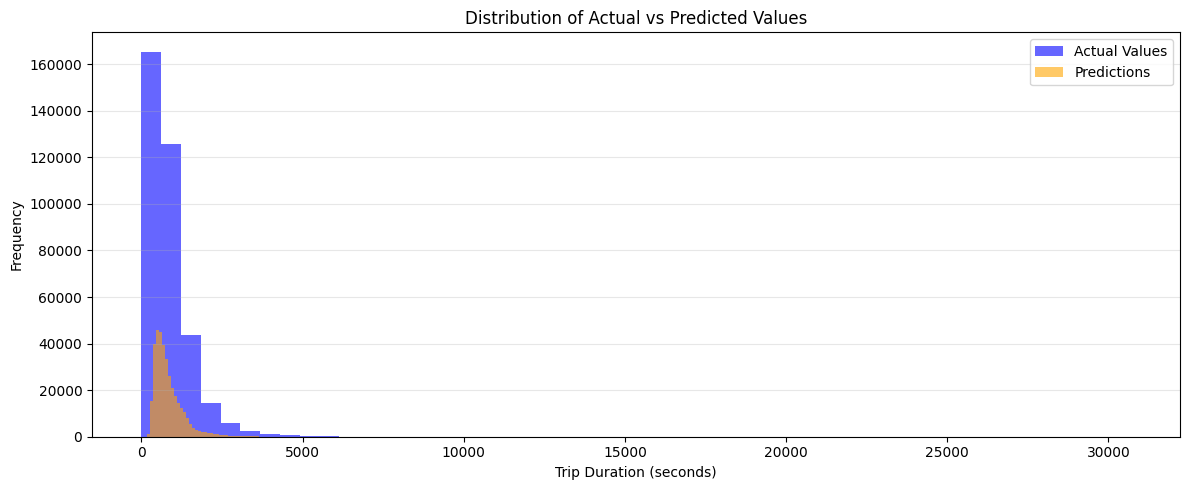

In [86]:
# 4. DISTRIBUTION COMPARISON - Histograms
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(val_target.values, bins=50, alpha=0.6, label='Actual Values', color='blue')
ax.hist(xgb_val_prediction, bins=50, alpha=0.6, label='Predictions', color='orange')
ax.set_xlabel('Trip Duration (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Actual vs Predicted Values')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

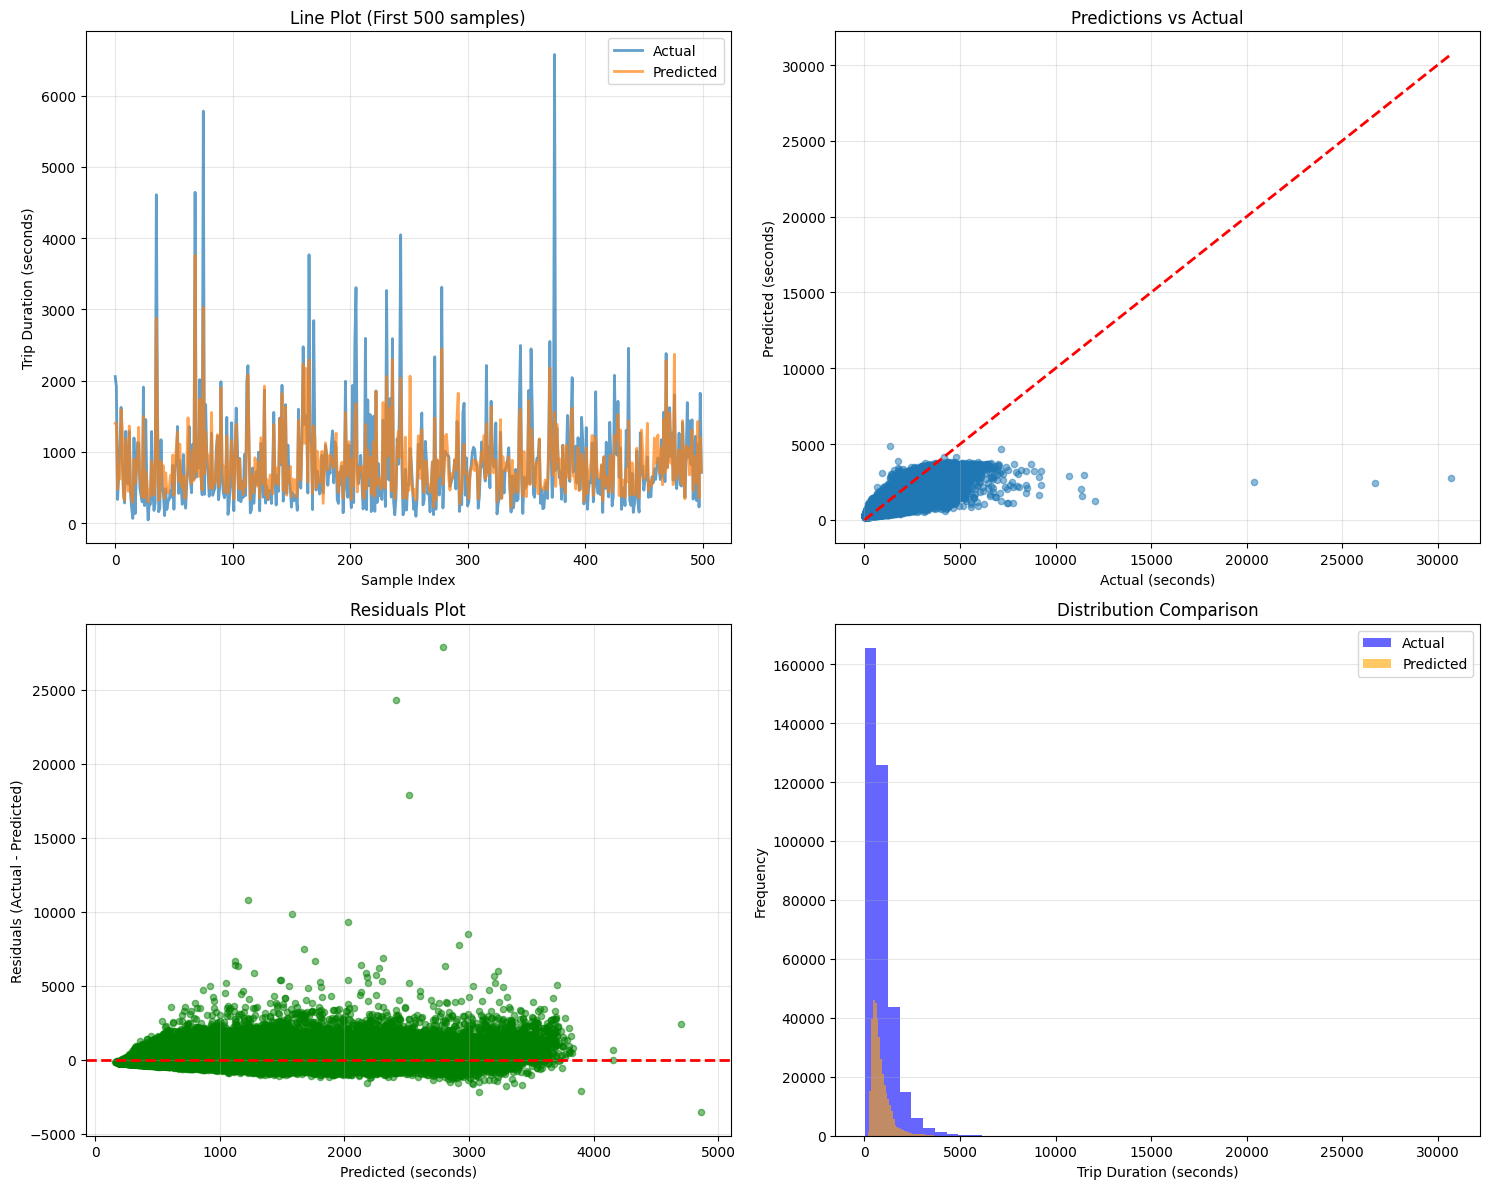

In [87]:
# 5. COMPREHENSIVE COMPARISON - 2x2 Subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Line plot
axes[0, 0].plot(val_target.values[:500], label='Actual', linewidth=2, alpha=0.7)
axes[0, 0].plot(xgb_val_prediction[:500], label='Predicted', linewidth=2, alpha=0.7)
axes[0, 0].set_title('Line Plot (First 500 samples)')
axes[0, 0].set_xlabel('Sample Index')
axes[0, 0].set_ylabel('Trip Duration (seconds)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Subplot 2: Scatter plot
axes[0, 1].scatter(val_target.values, xgb_val_prediction, alpha=0.5, s=20)
min_val = min(val_target.min(), xgb_val_prediction.min())
max_val = max(val_target.max(), xgb_val_prediction.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0, 1].set_title('Predictions vs Actual')
axes[0, 1].set_xlabel('Actual (seconds)')
axes[0, 1].set_ylabel('Predicted (seconds)')
axes[0, 1].grid(True, alpha=0.3)

# Subplot 3: Residuals
residuals = val_target.values - xgb_val_prediction
axes[1, 0].scatter(xgb_val_prediction, residuals, alpha=0.5, s=20, color='green')
axes[1, 0].axhline(y=0, color='r', lw=2, linestyle='--')
axes[1, 0].set_title('Residuals Plot')
axes[1, 0].set_xlabel('Predicted (seconds)')
axes[1, 0].set_ylabel('Residuals (Actual - Predicted)')
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Distribution
axes[1, 1].hist(val_target.values, bins=50, alpha=0.6, label='Actual', color='blue')
axes[1, 1].hist(xgb_val_prediction, bins=50, alpha=0.6, label='Predicted', color='orange')
axes[1, 1].set_title('Distribution Comparison')
axes[1, 1].set_xlabel('Trip Duration (seconds)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [88]:
# 6. ERROR ANALYSIS - Summary Statistics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

residuals = val_target.values - xgb_val_prediction

print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"\nActual Target Statistics:")
print(f"  Mean: {val_target.mean():.2f} seconds")
print(f"  Std Dev: {val_target.std():.2f} seconds")
print(f"  Min: {val_target.min():.2f} seconds")
print(f"  Max: {val_target.max():.2f} seconds")

print(f"\nPrediction Statistics:")
print(f"  Mean: {xgb_val_prediction.mean():.2f} seconds")
print(f"  Std Dev: {xgb_val_prediction.std():.2f} seconds")
print(f"  Min: {xgb_val_prediction.min():.2f} seconds")
print(f"  Max: {xgb_val_prediction.max():.2f} seconds")

print(f"\nError Statistics:")
print(f"  Mean Absolute Error (MAE): {mean_absolute_error(val_target, xgb_val_prediction):.2f} seconds")
print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(val_target, xgb_val_prediction)):.2f} seconds")
print(f"  Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(val_target, xgb_val_prediction):.4f}")
print(f"  R² Score: {r2_score(val_target, xgb_val_prediction):.4f}")

print(f"\nResidual Statistics:")
print(f"  Mean Residual: {residuals.mean():.2f} (should be close to 0)")
print(f"  Std Dev of Residuals: {residuals.std():.2f} seconds")
print(f"  Max Error: {abs(residuals).max():.2f} seconds")
print(f"  Percentage of predictions within 10% error: {(abs(residuals) / val_target.values < 0.1).sum() / len(residuals) * 100:.2f}%")
print("=" * 60)

MODEL PERFORMANCE SUMMARY

Actual Target Statistics:
  Mean: 837.54 seconds
  Std Dev: 657.89 seconds
  Min: 1.00 seconds
  Max: 30686.00 seconds

Prediction Statistics:
  Mean: 838.16 seconds
  Std Dev: 475.66 seconds
  Min: 161.45 seconds
  Max: 4863.05 seconds

Error Statistics:
  Mean Absolute Error (MAE): 217.77 seconds
  Root Mean Squared Error (RMSE): 334.68 seconds
  Mean Absolute Percentage Error (MAPE): 0.4013
  R² Score: 0.7412

Residual Statistics:
  Mean Residual: -0.61 (should be close to 0)
  Std Dev of Residuals: 334.68 seconds
  Max Error: 27897.84 seconds
  Percentage of predictions within 10% error: 22.48%


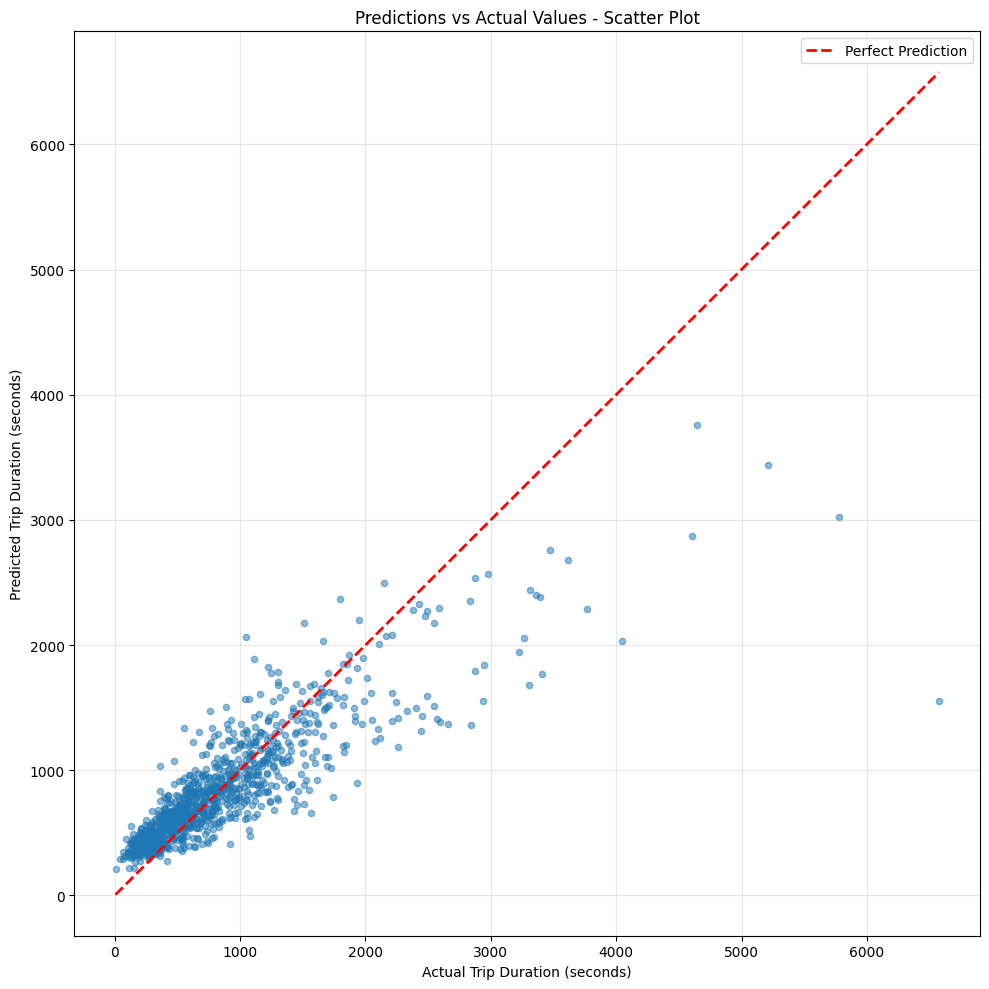

In [123]:
# 2. SCATTER PLOT - Predictions vs Actual (Perfect fit = diagonal line)
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(val_target[:1000].values, xgb_val_prediction[:1000], alpha=0.5, s=20)
# Add diagonal line for perfect prediction
min_val = min(val_target[:1000].min(), xgb_val_prediction[:1000].min())
max_val = max(val_target[:1000].max(), xgb_val_prediction[:1000].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Trip Duration (seconds)')
ax.set_ylabel('Predicted Trip Duration (seconds)')
ax.set_title('Predictions vs Actual Values - Scatter Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

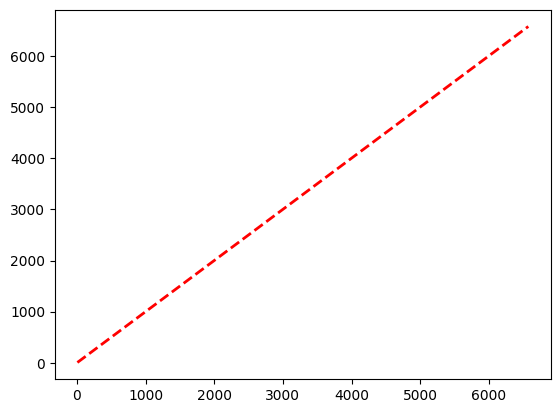

In [124]:
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')